In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [3]:
# --- Add parent directory to sys.path ---
import sys
import os

# Go one level up from notebooks/ → project root
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now imports from 'fcc' will work
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinSolver
import fcc

# --- Standard Python Imports ---
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import ray
from tqdm import tqdm
import psutil
import numpy as np
from time import time
import json

## Step 1: Make sure fcc is a valid package with __init__.py (you already confirmed this)
# Step 2: Use absolute path to fcc module
fcc_path = os.path.abspath("../fcc")  # one level up from 'notebooks/'
print(f"Using fcc path: {fcc_path}")

# Step 3: Init Ray using py_modules
num_workers = psutil.cpu_count(logical=False)
print(f"Number of workers: {num_workers}")

ray.shutdown()  # clean up any previous session
ray.init(
    num_cpus=num_workers,
    ignore_reinit_error=True,
    log_to_driver=False,
    runtime_env={
        "py_modules": [fcc_path],
    },
)

Using fcc path: c:\Users\8J6010897\Documents\GitHub\protein-folding-qc\fcc
Number of workers: 8


2025-05-08 16:23:54,948	INFO worker.py:1762 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8267 
2025-05-08 16:23:55,095	INFO packaging.py:530 -- Creating a file package for local directory 'c:\Users\8J6010897\Documents\GitHub\protein-folding-qc\fcc'.
2025-05-08 16:23:55,166	INFO packaging.py:358 -- Pushing file package 'gcs://_ray_pkg_43175c892223db71.zip' (0.27MiB) to Ray cluster...
2025-05-08 16:23:55,168	INFO packaging.py:371 -- Successfully pushed file package 'gcs://_ray_pkg_43175c892223db71.zip'.


Python version:,3.10.16
Ray version:,2.31.0
Dashboard:,http://127.0.0.1:8267


In [4]:
@ray.remote
def check_import():
    import fcc
    return dir(fcc)

print("Ray worker import test:", ray.get(check_import.remote()))

Ray worker import test: ['MiyazawaJerniganInteraction', 'PenaltyParameters', 'Peptide', 'ProteinFoldingProblem', 'ProteinFoldingResult', 'ProteinSolver', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'fcc_bead', 'fcc_contact_map', 'fcc_distance_map', 'fcc_mj_interaction', 'fcc_penalty_parameters', 'fcc_peptide', 'fcc_protein_folding_problem', 'fcc_protein_folding_result', 'fcc_protein_shape', 'fcc_qubit_op_builder', 'fcc_solver', 'measurement_utils', 'utils']


In [5]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

In [6]:
cs_dir = "../classical_search/cs_res/"
# file_name = f"{main_seq}_topobj.txt"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

In [7]:
shots = 10_000
sampler = Sampler(
    default_shots=shots, options={"backend_options": {"method": "matrix_product_state"}}
)

optimizer = "COBYLA"
maxiter = 500
num_batches = num_workers

In [8]:
cls_file_name = "6AA_KLVFFA_topobj.txt"
top_cls_turns = load_top_cls_solns(cls_file_name)
len(top_cls_turns)

50

In [9]:
main_seq = "KLVFFA" 
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []
top_turns_list = []

r2_thresholds = [0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_list.append(opt_results["top_solutions"][:50])
    top_turns_per_r2 = [[convert_bitstring_to_turns(soln[0], main_seq), soln[1]] for soln in opt_results["top_solutions"][:50]]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/7 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0010082721710205078
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0009918212890625
h_op size @ k = 5: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.004999876022338867
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.014003992080688477
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.014006376266479492
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.015018701553344727
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.01551961898803711
h_op size @ k = 6: 1024
Beads 0 and 5 -- dist_op size: 411
h_op size @ k = 1: 411
Time taken to do composition @ k = 2: 0.04699230194091797
h_op size @ k = 2: 8124
Time taken to do composition @ k = 3: 0.37042

 14%|█▍        | 1/7 [08:20<50:02, 500.34s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00099945068359375
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00099945068359375
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0005211830139160156
h_op size @ k = 5: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.008036136627197266
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.019746065139770508
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.01773238182067871
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.017058372497558594
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.017299652099609375
h_op size @ k = 6: 1024
Time taken to do composition @ k = 7: 0.018225431442260742
h_op size @ k = 7: 1024
Beads 0 and 5 -- dist_op size: 411
h_op size @ k = 1: 411
Time taken to do compositio

 29%|██▊       | 2/7 [16:18<40:37, 487.42s/it]

...

 71%|███████▏  | 5/7 [40:23<16:13, 486.57s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0010166168212890625
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0009968280792236328
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0010666847229003906
h_op size @ k = 6: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.005992889404296875
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.015123844146728516
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.016259431838989258
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.018152952194213867
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.015057802200317383
h_op size @ k = 6: 1024
Time taken to do composition @ k = 7: 0.014083385467529297
h_op size @ k = 7: 1024
Time taken to do

 86%|████████▌ | 6/7 [47:30<07:46, 466.36s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0010006427764892578
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0009996891021728516
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0010001659393310547
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.006020784378051758
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.013428926467895508
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.01683521270751953
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.014962196350097656
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.015137672424316406
h_op size @ k = 6: 1024
Time taken to do composition @ k = 7

100%|██████████| 7/7 [56:12<00:00, 481.75s/it]


In [17]:
print(opt_results.keys())

dict_keys(['final_cost', 'opt_params', 'cost_trajectory', 'top_solutions'])


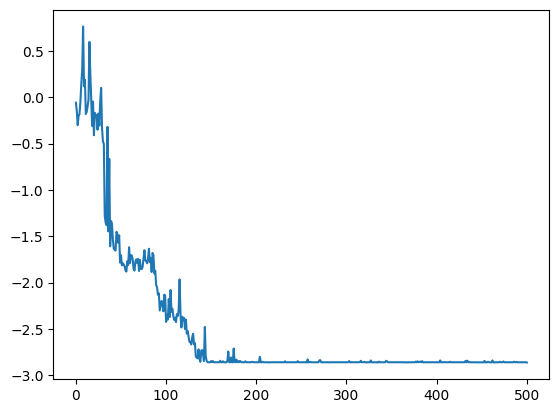

In [18]:
plt.plot(opt_results['cost_trajectory'])

In [10]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]
top_cls_turns

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33],
 ['1a180', -30.33],
 ['68b90', -30.25],
 ['02180', -30.23],
 ['70390', -30.13],
 ['68390', -30.13],
 ['82180', -30.13],
 ['07490', -30.13],
 ['7b090', -29.56],
 ['91820', -29.56],
 ['b1a20', -29.56]]

In [11]:
top_bitstrings_list[-1][:20]

[('101110101101100000111010', -3.0971658812923124),
 ('101000000000001110010100', -2.9929262624516904),
 ('101110001101100000111010', -2.9661658812923126),
 ('101000000000110001010100', -2.927939126571907),
 ('100111110010011100001000', -2.8702868737697886),
 ('101110000011101010001100', -2.859221082664855),
 ('101110000000100110001100', -2.8592210825273545),
 ('101110000001100010111100', -2.8592210822613406),
 ('101110000010101110111100', -2.8592210822151616),
 ('100000000100000010101010', -2.838736054699436),
 ('101110100101100000111010', -2.7611658812923126),
 ('101110111101100000111010', -2.7611658812923126),
 ('101111000011001101011000', -2.7547315214500685),
 ('101100000011000101111000', -2.7547315213165495),
 ('101000000111010011101010', -2.7331602100837022),
 ('101110100011101010001100', -2.7282210826648554),
 ('101110100000100110001100', -2.728221082527355),
 ('101110100001100010111100', -2.7282210822613413),
 ('101110100010101110111100', -2.7282210822151614),
 ('1011100010011

In [12]:
# Top 20 solutions from VQE (R^2 = 0.999)
top_turns_list[-1][:20]

[['70b90', -3.0971658812923124],
 ['0b600', -2.9929262624516904],
 ['70b90', -2.9661658812923126],
 ['28600', -2.927939126571907],
 ['41900', -2.8702868737697886],
 ['b5200', -2.859221082664855],
 ['97200', -2.8592210825273545],
 ['79300', -2.8592210822613406],
 ['5b300', -2.8592210822151616],
 ['09590', -2.838736054699436],
 ['70b90', -2.7611658812923126],
 ['70b90', -2.7611658812923126],
 ['1a700', -2.7547315214500685],
 ['16b00', -2.7547315213165495],
 ['a2590', -2.7331602100837022],
 ['b5200', -2.7282210826648554],
 ['97200', -2.728221082527355],
 ['79300', -2.7282210822613413],
 ['5b300', -2.7282210822151614],
 ['70b90', -2.7171658812923125]]

In [14]:
print(f"Ground state by classical search: {top_cls_turns[0]}")
for r2_threshold in r2_thresholds:
    print(f"R^2 threshold: {r2_threshold}")
    best_solution = top_turns_list[r2_thresholds.index(r2_threshold)][0], top_turns_list[r2_thresholds.index(r2_threshold)][1], top_turns_list[r2_thresholds.index(r2_threshold)][2], top_turns_list[r2_thresholds.index(r2_threshold)][3]
    print(f"VQE best solution: {best_solution}")

Ground state by classical search: ['97490', -30.57]
R^2 threshold: 0.95
VQE best solution: (['19500', -15.028129016938294], ['11480', -14.477129016938164], ['09500', -14.250303546524249], ['25a20', -14.233363271004231])
R^2 threshold: 0.96
VQE best solution: (['17b00', -11.645896623261462], ['1b700', -11.64589662326066], ['19500', -11.645896623257904], ['11480', -11.546896623263377])
R^2 threshold: 0.97
VQE best solution: (['11480', -11.546896623263377], ['80590', -11.436842605946554], ['80590', -11.187842605946553], ['80590', -11.100842605946553])
R^2 threshold: 0.98
VQE best solution: (['80580', -10.945933497586147], ['90490', -10.87462393163769], ['11480', -10.818896623263377], ['11480', -10.799896623263377])
R^2 threshold: 0.99
VQE best solution: (['80580', -6.285774470268471], ['80580', -5.949774470268472], ['18500', -5.916523560391963], ['80580', -5.881774470268471])
R^2 threshold: 0.995
VQE best solution: (['80580', -7.168929570519614], ['80580', -6.832929570519615], ['80580', -